## **Supervised Model III – XGBoost (Cleaned)**

Key fixes from XGBoost_improved4:
1. **Fix 1 — Structural feature leakage** (cells 7, 10, 11, 14, 26):
New function compute_structural_refs(XX_train) extracts the global rating distribution and top-100 item set from training data only. build_structural_features now takes these as a parameter instead of computing them from whatever XX it receives. So validation and test users get their kl_div_from_global and frac_top100_items measured against the training distribution, not their own. The refs are computed once per fold in make_fold_features, stored in fold_artifacts, and passed through at test time.

2. **Fix 2 — Calibration alignment** (cells 11, 19, 21, 22):
make_fold_features now returns val_recon_mse (the SVD reconstruction MSE for validation users). The CV loop stores these into oof_recon_mse. The calibration cell then blends oof_scores with oof_recon_norm at BLEND_ALPHA = 0.15 before fitting the calibrator. This means the calibrator learns the mapping from blended scores → labels, matching exactly what happens at test time. The threshold analysis also runs on blended+calibrated scores, so the reported optimal F1 threshold should land much closer to 0.5 than the 0.310 you saw before.

3. **Fix 3 — Early stopping** (cell 19):
model.fit now includes eval_set=[(X_va, y_va)] and early_stopping_rounds=50. The fold printout also shows trees: {model.best_iteration + 1} so you can see how many trees each fold actually used versus the n_estimators ceiling from Optuna. This prevents the model from training past the point Optuna's hyperparameter search assumed was optimal.

In [1]:
results = []

In [2]:
import matplotlib.pyplot as plt
import zipfile, warnings
import xgboost as xgb
import pandas as pd
import numpy as np
import optuna
from scipy.stats import entropy
from scipy.spatial.distance import mahalanobis
from scipy.sparse import csr_matrix
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import TruncatedSVD, NMF

warnings.filterwarnings('ignore')

TOTAL_ITEMS = 1000
RATING_RANGE = range(6)
N_SVD_COMPONENTS = 50

/Users/tori/Documents/OFFICES/SCHOOL/Y3S2/Machine_Learning_421_SMU/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### **Data Loading**

In [3]:
# ── I/O helpers ──────────────────────────────────────────────────────

def load_npz(path: str) -> tuple[pd.DataFrame, pd.DataFrame | None]:
    data = np.load(path)
    XX = pd.DataFrame(data["X"], columns=["user", "item", "rating"])
    yy = None
    if "y" in data:
        yy = pd.DataFrame(data["y"], columns=["user", "label"])
    return XX, yy


def combine_labeled_data(
    *npz_paths: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    all_X, all_y = [], []
    for path in npz_paths:
        data = np.load(path)
        all_X.append(pd.DataFrame(data["X"], columns=["user", "item", "rating"]))
        all_y.append(pd.DataFrame(data["y"], columns=["user", "label"]))

    XX = pd.concat(all_X, ignore_index=True)
    yy = pd.concat(all_y, ignore_index=True).drop_duplicates(subset="user", keep="first")

    n_anom = int(yy["label"].sum())
    print(f"Combined {len(npz_paths)} files")
    print(f"{yy.shape[0]} users ({n_anom} anomalous, {yy.shape[0] - n_anom} normal), {XX.shape[0]} interactions")
    return XX, yy

In [4]:
# ── Sparse matrix builder ────────────────────────────────────────────

def build_user_item_matrix(XX: pd.DataFrame, user_ids: np.ndarray):
    """Build a sparse user×item rating matrix.
    
    Returns:
        mat: sparse CSR matrix (n_users × TOTAL_ITEMS)
        uid_to_row: dict mapping user_id → row index
    """
    uid_to_row = {uid: i for i, uid in enumerate(user_ids)}

    # Vectorised — avoid iterrows on 400k+ rows
    mask = XX["user"].isin(uid_to_row)
    sub = XX.loc[mask]
    rows = sub["user"].map(uid_to_row).values
    cols = sub["item"].values.astype(int)
    vals = sub["rating"].values.astype(float)

    mat = csr_matrix((vals, (rows, cols)), shape=(len(user_ids), TOTAL_ITEMS))
    return mat, uid_to_row

In [5]:
# ── Original hand-crafted features (kept from your notebook) ────────

def compute_item_stats(XX_train: pd.DataFrame) -> dict:
    item_avg = XX_train.groupby("item")["rating"].mean().rename("item_avg_rating")
    item_pop = XX_train.groupby("item")["user"].count().rename("item_popularity")
    return {"item_avg_rating": item_avg, "item_popularity": item_pop}


def build_handcrafted_features(
    XX: pd.DataFrame,
    item_stats: dict,
    total_items: int = TOTAL_ITEMS,
) -> pd.DataFrame:
    """Original 24 features — unchanged from your notebook."""
    item_avg = item_stats["item_avg_rating"]
    item_pop = item_stats["item_popularity"]

    stats = XX.groupby("user")["rating"].agg(
        rating_mean="mean", rating_std="std", rating_median="median",
        rating_min="min", rating_max="max", rating_count="count",
    )
    stats["rating_std"] = stats["rating_std"].fillna(0)
    stats["rating_range"] = stats["rating_max"] - stats["rating_min"]

    rdist = XX.groupby(["user", "rating"]).size().unstack(fill_value=0)
    rdist = rdist.reindex(columns=RATING_RANGE, fill_value=0)
    rprops = rdist.div(rdist.sum(axis=1), axis=0)
    rprops.columns = [f"prop_rating_{i}" for i in RATING_RANGE]
    stats["rating_entropy"] = rprops.apply(
        lambda row: entropy(row.values[row.values > 0]), axis=1
    )
    stats = stats.join(rprops)
    stats["prop_extreme"] = rprops["prop_rating_0"] + rprops["prop_rating_5"]

    stats["unique_items_rated"] = XX.groupby("user")["item"].nunique()
    stats["item_coverage_ratio"] = stats["unique_items_rated"] / total_items

    XX_pop = XX.merge(item_pop, left_on="item", right_index=True, how="left")
    XX_pop["item_popularity"] = XX_pop["item_popularity"].fillna(0)
    pop_f = XX_pop.groupby("user")["item_popularity"].agg(
        avg_item_popularity="mean", std_item_popularity="std",
    )
    pop_f["std_item_popularity"] = pop_f["std_item_popularity"].fillna(0)
    stats = stats.join(pop_f)

    XX_dev = XX.merge(item_avg, left_on="item", right_index=True, how="left")
    global_train_mean = item_avg.mean()
    XX_dev["item_avg_rating"] = XX_dev["item_avg_rating"].fillna(global_train_mean)
    XX_dev["deviation"] = XX_dev["rating"] - XX_dev["item_avg_rating"]
    dev_f = XX_dev.groupby("user")["deviation"].agg(
        mean_deviation="mean", std_deviation="std",
        abs_mean_deviation=lambda x: np.mean(np.abs(x)),
    )
    dev_f["std_deviation"] = dev_f["std_deviation"].fillna(0)
    stats = stats.join(dev_f)

    iqf = XX_dev.groupby("user")["item_avg_rating"].agg(
        avg_item_avg_rating="mean", std_item_avg_rating="std",
    )
    iqf["std_item_avg_rating"] = iqf["std_item_avg_rating"].fillna(0)
    stats = stats.join(iqf)

    return stats.reset_index()

In [6]:
# ── Structural features (with reference stats to prevent leakage) ────

def compute_structural_refs(XX_train: pd.DataFrame) -> dict:
    """Compute reference statistics from TRAINING data only.
    Pass the returned dict to build_structural_features for both
    train and test/val to prevent leakage.
    """
    global_dist = XX_train["rating"].value_counts(normalize=True).reindex(RATING_RANGE, fill_value=0).values
    global_dist = np.clip(global_dist, 1e-10, None)
    top_items = set(XX_train["item"].value_counts().head(100).index)
    return {"global_dist": global_dist, "top_items": top_items}


def build_structural_features(
    XX: pd.DataFrame,
    structural_refs: dict,
) -> pd.DataFrame:
    """Features that capture the *shape* of a user's behaviour.
    Uses frozen reference stats from training data for KL divergence
    and top-item overlap to prevent train/val leakage.
    """
    feats = pd.DataFrame({"user": XX["user"].unique()})

    # ── KL divergence from TRAINING global distribution ────────────
    ref_dist = structural_refs["global_dist"]

    def user_kl(group):
        user_dist = group["rating"].value_counts(normalize=True).reindex(RATING_RANGE, fill_value=0).values
        user_dist = np.clip(user_dist, 1e-10, None)
        return entropy(user_dist, ref_dist)

    kl_df = XX.groupby("user").apply(user_kl).rename("kl_div_from_global")
    feats = feats.merge(kl_df, on="user", how="left")

    # ── Gini coefficient of item selection ────────────────────────
    def gini_coeff(group):
        counts = group["item"].value_counts().values.astype(float)
        if len(counts) <= 1:
            return 0.0
        counts = np.sort(counts)
        n = len(counts)
        index = np.arange(1, n + 1)
        return (2.0 * np.sum(index * counts) / (n * np.sum(counts))) - (n + 1.0) / n

    gini_df = XX.groupby("user").apply(gini_coeff).rename("item_gini")
    feats = feats.merge(gini_df, on="user", how="left")

    # ── Rating flatness ──────────────────────────────────────────
    def rating_flatness(group):
        ratings = group["rating"].values
        if len(ratings) <= 1:
            return 0.0
        vals, counts = np.unique(ratings, return_counts=True)
        return counts.max() / len(ratings)

    flat_df = XX.groupby("user").apply(rating_flatness).rename("rating_mode_frac")
    feats = feats.merge(flat_df, on="user", how="left")

    # ── Rating skewness & kurtosis ───────────────────────────────
    skew_df = XX.groupby("user")["rating"].skew().rename("rating_skew").fillna(0)
    kurt_df = XX.groupby("user")["rating"].apply(
        lambda x: x.kurtosis() if len(x) >= 4 else 0.0
    ).rename("rating_kurtosis")
    feats = feats.merge(skew_df, on="user", how="left")
    feats = feats.merge(kurt_df, on="user", how="left")

    # ── Item overlap with TRAINING top-100 items ─────────────────
    ref_top = structural_refs["top_items"]
    def top_item_frac(group):
        user_items = set(group["item"].values)
        return len(user_items & ref_top) / max(len(user_items), 1)

    top_df = XX.groupby("user").apply(top_item_frac).rename("frac_top100_items")
    feats = feats.merge(top_df, on="user", how="left")

    # ── Ratings-per-item ratio ───────────────────────────────────
    rpi = XX.groupby("user").apply(
        lambda g: len(g) / g["item"].nunique()
    ).rename("ratings_per_item")
    feats = feats.merge(rpi, on="user", how="left")

    return feats


In [7]:
# ── (SVD + unsupervised scoring merged into build_unsupervised_scores) ─
pass


In [8]:
# ── Unsupervised scores: curated from both latent + handcrafted space ──
#
# Latent-space diagnostics revealed:
#   - IF, Mahalanobis, latent_dist are ANTI-CORRELATED (AUC < 0.5)
#     → anomalies sit CLOSER to centroid than normals (hyper-normal)
#   - SVD recon MSE works (0.765) — anomalies are in the right
#     neighbourhood but their ratings are internally inconsistent
#   - Handcrafted-space scores were better (IF=0.692, Maha=0.751)
#
# Strategy: use SVD recon error from latent space + handcrafted-space
# IF/Mahalanobis. Drop all distance-from-centroid features.

def build_unsupervised_scores(
    XX_ref: pd.DataFrame,
    XX_target: pd.DataFrame,
    target_users: np.ndarray,
    ref_normal_users: np.ndarray,
    X_handcrafted_ref: np.ndarray,
    X_handcrafted_target: np.ndarray,
    ref_labels: np.ndarray,
    n_components: int = N_SVD_COMPONENTS,
) -> tuple[np.ndarray, TruncatedSVD]:
    """Compute curated unsupervised features.

    Returns (scores_array, svd_model) where scores_array has columns:
      [svd_recon_mse, svd_recon_mae, iso_handcrafted, maha_handcrafted]
    """
    # ─── A) SVD reconstruction error (latent space, normal-only fit) ───
    XX_normal = XX_ref[XX_ref["user"].isin(ref_normal_users)]
    normal_uids = XX_normal["user"].unique()
    normal_mat, _ = build_user_item_matrix(XX_normal, normal_uids)

    n_comp = min(n_components, min(normal_mat.shape) - 1)
    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    svd.fit(normal_mat)

    target_mat, _ = build_user_item_matrix(XX_target, target_users)
    latent = svd.transform(target_mat)
    reconstructed = latent @ svd.components_

    target_dense = target_mat.toarray()
    mask = (target_dense != 0).astype(float)
    diff = (target_dense - reconstructed) * mask
    n_rated = np.maximum(np.sum(mask, axis=1), 1)

    recon_mse = np.sum(diff ** 2, axis=1) / n_rated
    recon_mae = np.sum(np.abs(diff), axis=1) / n_rated

    # ─── B) IF + Mahalanobis on HANDCRAFTED features (normal-only fit) ─
    X_fit = X_handcrafted_ref[ref_labels == 0]

    iso = IsolationForest(
        n_estimators=500, contamination="auto", random_state=42, n_jobs=-1
    )
    iso.fit(X_fit)
    iso_scores = -iso.score_samples(X_handcrafted_target)

    try:
        mu = X_fit.mean(axis=0)
        cov = np.cov(X_fit, rowvar=False)
        cov += np.eye(cov.shape[0]) * 1e-6
        cov_inv = np.linalg.inv(cov)
        maha_scores = np.array([
            mahalanobis(x, mu, cov_inv) for x in X_handcrafted_target
        ])
    except Exception:
        mu = X_fit.mean(axis=0)
        maha_scores = np.linalg.norm(X_handcrafted_target - mu, axis=1)

    scores = np.column_stack([recon_mse, recon_mae, iso_scores, maha_scores])
    return scores, svd


UNSUP_COLS = [
    "svd_recon_mse", "svd_recon_mae",
    "iso_handcrafted", "maha_handcrafted",
]


In [9]:
# ── Combined feature pipeline ────────────────────────────────────────

def build_all_features(
    XX: pd.DataFrame,
    item_stats: dict,
    structural_refs: dict,
) -> pd.DataFrame:
    """Merge handcrafted + structural features.
    structural_refs must come from compute_structural_refs(XX_train).
    """
    hc = build_handcrafted_features(XX, item_stats)
    st = build_structural_features(XX, structural_refs)
    merged = hc.merge(st, on="user", how="left")
    return merged


In [10]:
# ── Fold feature builder ──────────────────────────────────────────────

def make_fold_features(XX_raw, yy_raw, train_users, val_users):
    XX_tr  = XX_raw[XX_raw["user"].isin(train_users)].copy()
    XX_val = XX_raw[XX_raw["user"].isin(val_users)].copy()
    yy_tr  = yy_raw[yy_raw["user"].isin(train_users)].copy()
    yy_val = yy_raw[yy_raw["user"].isin(val_users)].copy()

    normal_train_users = yy_tr[yy_tr["label"] == 0]["user"].values
    item_stats_tr = compute_item_stats(XX_tr)

    # FIX 1: Compute structural refs from TRAINING fold only
    struct_refs_tr = compute_structural_refs(XX_tr)

    # Handcrafted + structural features (both use training refs)
    feats_tr  = build_all_features(XX_tr, item_stats_tr, struct_refs_tr).merge(yy_tr, on="user")
    feats_val = build_all_features(XX_val, item_stats_tr, struct_refs_tr).merge(yy_val, on="user")

    hc_cols = [c for c in feats_tr.columns if c not in ["user", "label"]]

    scaler_fold = RobustScaler()
    X_tr_hc_s = scaler_fold.fit_transform(feats_tr[hc_cols].values)
    X_val_hc_s = scaler_fold.transform(feats_val[hc_cols].values)

    y_tr_labels = feats_tr["label"].values

    # Unsupervised: SVD recon (latent) + IF/Maha (handcrafted)
    unsup_tr, svd_model = build_unsupervised_scores(
        XX_ref=XX_tr, XX_target=XX_tr,
        target_users=feats_tr["user"].values,
        ref_normal_users=normal_train_users,
        X_handcrafted_ref=X_tr_hc_s,
        X_handcrafted_target=X_tr_hc_s,
        ref_labels=y_tr_labels,
    )
    unsup_val, _ = build_unsupervised_scores(
        XX_ref=XX_tr, XX_target=XX_val,
        target_users=feats_val["user"].values,
        ref_normal_users=normal_train_users,
        X_handcrafted_ref=X_tr_hc_s,
        X_handcrafted_target=X_val_hc_s,
        ref_labels=y_tr_labels,
    )

    X_tr_final  = np.hstack([X_tr_hc_s, unsup_tr])
    X_val_final = np.hstack([X_val_hc_s, unsup_val])
    feature_cols_all = hc_cols + UNSUP_COLS

    # FIX 2: Return val SVD recon MSE for blended calibration
    val_recon_mse = unsup_val[:, 0]  # column 0 = svd_recon_mse

    return (
        X_tr_final, feats_tr["label"].values,
        X_val_final, feats_val["label"].values,
        item_stats_tr, feature_cols_all, scaler_fold, svd_model,
        normal_train_users, struct_refs_tr, val_recon_mse,
    )


In [11]:
# ── Evaluation helper ────────────────────────────────────────────────

def codabench_metrics(test_labels, scores, model_name, verbose=False):
    test_labels = np.asarray(test_labels).astype(int)
    scores = np.asarray(scores).astype(float)
    preds = (scores >= 0.5).astype(int)
    metrics = {
        "model": model_name,
        "AUC": roc_auc_score(test_labels, scores),
        "Precision": precision_score(test_labels, preds, zero_division=0),
        "Recall": recall_score(test_labels, preds, zero_division=0),
        "F1": f1_score(test_labels, preds, zero_division=0),
        "threshold": 0.5,
    }
    if verbose:
        print(f"{model_name} (Codabench t=0.5)")
        for k in ["AUC", "Precision", "Recall", "F1"]:
            print(f"# {k+':':12s} {metrics[k]:.4f}")
    return metrics

In [12]:
# Phase 3 data loading
XX_all, yy_all = combine_labeled_data(
    "data/training_batch_with_labels.npz",
    "data/first_batch_with_labels.npz",
    "data/second_batch_with_labels.npz",
)

Combined 3 files
3060 users (260 anomalous, 2800 normal), 479433 interactions


In [13]:
# Build full feature set for Optuna
item_stats_full = compute_item_stats(XX_all)
struct_refs_full = compute_structural_refs(XX_all)
full_train_df = build_all_features(XX_all, item_stats_full, struct_refs_full).merge(yy_all, on="user")

normal_users_all = yy_all[yy_all["label"] == 0]["user"].values
hc_cols = [c for c in full_train_df.columns if c not in ["user", "label"]]

scaler = RobustScaler()
X_hc_s = scaler.fit_transform(full_train_df[hc_cols].values)
y_trainval = full_train_df["label"].values

# Unsupervised scores
unsup_all, svd_full_model = build_unsupervised_scores(
    XX_ref=XX_all, XX_target=XX_all,
    target_users=full_train_df["user"].values,
    ref_normal_users=normal_users_all,
    X_handcrafted_ref=X_hc_s,
    X_handcrafted_target=X_hc_s,
    ref_labels=y_trainval,
)

X_trainval_s = np.hstack([X_hc_s, unsup_all])
feature_cols = hc_cols
feature_cols_all = hc_cols + UNSUP_COLS

print(f"Training users: {len(y_trainval)}")
print(f"Features:       {len(feature_cols_all)}")
print(f"Feature names:  {feature_cols_all}")


Training users: 3060
Features:       35
Feature names:  ['rating_mean', 'rating_std', 'rating_median', 'rating_min', 'rating_max', 'rating_count', 'rating_range', 'rating_entropy', 'prop_rating_0', 'prop_rating_1', 'prop_rating_2', 'prop_rating_3', 'prop_rating_4', 'prop_rating_5', 'prop_extreme', 'unique_items_rated', 'item_coverage_ratio', 'avg_item_popularity', 'std_item_popularity', 'mean_deviation', 'std_deviation', 'abs_mean_deviation', 'avg_item_avg_rating', 'std_item_avg_rating', 'kl_div_from_global', 'item_gini', 'rating_mode_frac', 'rating_skew', 'rating_kurtosis', 'frac_top100_items', 'ratings_per_item', 'svd_recon_mse', 'svd_recon_mae', 'iso_handcrafted', 'maha_handcrafted']


#### **Optuna Hyperparameter Search (F1-optimised)**

In [14]:
from sklearn.metrics import fbeta_score

spw_global = np.sum(y_trainval == 0) / np.sum(y_trainval == 1)
OPTUNA_BETA = 1.5  # >1 biases toward recall; try 1.5 or 2.0

def objective(trial):
    grow_policy = trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])

    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 100, 4000),
        learning_rate     = trial.suggest_float("learning_rate", 0.001, 0.15, log=True),
        subsample         = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
        colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        colsample_bynode  = trial.suggest_float("colsample_bynode", 0.4, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 1, 10),
        gamma             = trial.suggest_float("gamma", 0.0, 2.0),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        max_delta_step    = trial.suggest_int("max_delta_step", 0, 10),
        scale_pos_weight  = trial.suggest_float("scale_pos_weight", spw_global * 0.5, spw_global * 3.0),
        grow_policy       = grow_policy,
    )

    if grow_policy == "lossguide":
        params["max_leaves"] = trial.suggest_int("max_leaves", 16, 512)
    else:
        params["max_depth"] = trial.suggest_int("max_depth", 3, 12)

    # 5-fold CV, optimise for F-beta (recall-biased)
    # NOTE: minor leakage in unsup scores for speed; proper CV below.
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=trial.number)
    fold_fbetas = []
    fold_f1s = []
    fold_aucs = []

    for tr_i, val_i in cv.split(X_trainval_s, y_trainval):
        m = xgb.XGBClassifier(
            **params,
            eval_metric="aucpr",
            early_stopping_rounds=50,
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
        )
        m.fit(
            X_trainval_s[tr_i], y_trainval[tr_i],
            eval_set=[(X_trainval_s[val_i], y_trainval[val_i])],
            verbose=False,
        )
        proba = m.predict_proba(X_trainval_s[val_i])[:, 1]
        preds = (proba >= 0.5).astype(int)
        fold_fbetas.append(fbeta_score(y_trainval[val_i], preds, beta=OPTUNA_BETA, zero_division=0))
        fold_f1s.append(f1_score(y_trainval[val_i], preds, zero_division=0))
        fold_aucs.append(roc_auc_score(y_trainval[val_i], proba))

    trial.set_user_attr("mean_auc", np.mean(fold_aucs))
    trial.set_user_attr("mean_f1", np.mean(fold_f1s))
    return np.mean(fold_fbetas)


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300, show_progress_bar=True)


[I 2026-03-30 19:29:05,260] A new study created in memory with name: no-name-3469db4f-8d7a-4d8d-8f76-359c435f56c6
Best trial: 0. Best value: 0.374114:   0%|          | 1/300 [00:02<10:17,  2.07s/it]

[I 2026-03-30 19:29:07,326] Trial 0 finished with value: 0.3741140005648807 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 3006, 'learning_rate': 0.0010090571495319312, 'subsample': 0.6023483110708108, 'colsample_bytree': 0.9471304599377743, 'colsample_bylevel': 0.950908534714329, 'colsample_bynode': 0.5368630085431753, 'min_child_weight': 4, 'gamma': 1.005281211790639, 'reg_alpha': 0.0002919499480099881, 'reg_lambda': 0.010705854053354225, 'max_delta_step': 8, 'scale_pos_weight': 9.102088723422964, 'max_depth': 12}. Best is trial 0 with value: 0.3741140005648807.


Best trial: 1. Best value: 0.781723:   1%|          | 2/300 [00:03<08:29,  1.71s/it]

[I 2026-03-30 19:29:08,788] Trial 1 finished with value: 0.7817231835616495 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 2873, 'learning_rate': 0.05039994216165181, 'subsample': 0.7475457764386344, 'colsample_bytree': 0.9641562795461913, 'colsample_bylevel': 0.5670495999452941, 'colsample_bynode': 0.6878985381728598, 'min_child_weight': 5, 'gamma': 0.15057857807650166, 'reg_alpha': 0.007170255069489519, 'reg_lambda': 0.00012791288217350375, 'max_delta_step': 8, 'scale_pos_weight': 6.159186090300929, 'max_depth': 3}. Best is trial 1 with value: 0.7817231835616495.


Best trial: 2. Best value: 0.785072:   1%|          | 3/300 [00:06<10:42,  2.16s/it]

...

[I 2026-03-30 19:31:18,506] Trial 45 finished with value: 0.7695358767659404 and parameters: {'grow_policy': 'lossguide', 'n_estimators': 2129, 'learning_rate': 0.1202923848812624, 'subsample': 0.70136057287193, 'colsample_bytree': 0.916683286291112, 'colsample_bylevel': 0.8267921600536171, 'colsample_bynode': 0.42744770725142933, 'min_child_weight': 6, 'gamma': 0.5802077288881531, 'reg_alpha': 0.22972638192356126, 'reg_lambda': 0.33280984102414235, 'max_delta_step': 6, 'scale_pos_weight': 11.570848974764502, 'max_leaves': 239}. Best is trial 2 with value: 0.7850720398795547.


Best trial: 2. Best value: 0.785072:  16%|█▌        | 47/300 [02:15<10:47,  2.56s/it]

[I 2026-03-30 19:31:20,775] Trial 46 finished with value: 0.7798657286559603 and parameters: {'grow_policy': 'lossguide', 'n_estimators': 3033, 'learning_rate': 0.1389919629141449, 'subsample': 0.7957816267596721, 'colsample_bytree': 0.7796932145151834, 'colsample_bylevel': 0.8834255814076112, 'colsample_bynode': 0.6191383423494659, 'min_child_weight': 5, 'gamma': 0.08480320549725823, 'reg_alpha': 2.64011248993153, 'reg_lambda': 0.8970268364070282, 'max_delta_step': 7, 'scale_pos_weight': 6.871107280288118, 'max_leaves': 197}. Best is trial 2 with value: 0.7850720398795547.


Best trial: 2. Best value: 0.785072:  16%|█▌        | 48/300 [02:16<08:57,  2.13s/it]

[I 2026-03-30 19:31:21,914] Trial 47 finished with value: 0.7671777197210994 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 3050, 'learning_rate': 0.14071167702474072, 'subsample': 0.7987435154777408, 'colsample_bytree': 0.8027092227973207, 'colsample_bylevel': 0.9462605758198245, 'colsample_bynode': 0.6373526309107356, 'min_child_weight': 5, 'gamma': 0.07069115718717567, 'reg_alpha': 2.8238054278867577, 'reg_lambda': 0.8577275851699399, 'max_delta_step': 9, 'scale_pos_weight': 6.773892360503406, 'max_depth': 3}. Best is trial 2 with value: 0.7850720398795547.


In [ ]:
best_params = study.best_params
print(f"Best CV F-beta({OPTUNA_BETA}): {study.best_value:.4f}")
print(f"Best CV F1:         {study.best_trial.user_attrs['mean_f1']:.4f}")
print(f"Best CV AUC:        {study.best_trial.user_attrs['mean_auc']:.4f}")
print("Best params:", best_params)

#### **Cross-Validation (5-fold)**

In [ ]:
N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_scores = np.zeros(len(y_trainval))
oof_recon_mse = np.zeros(len(y_trainval))  # FIX 2: for blended calibration
fold_aucs = []
fold_f1s  = []
fold_artifacts = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(full_train_df[feature_cols].values, y_trainval), 1):
    train_users = full_train_df.iloc[tr_idx]["user"].values
    val_users   = full_train_df.iloc[va_idx]["user"].values

    X_tr, y_tr, X_va, y_va, item_stats_tr, feat_cols_fold, scaler_fold, svd_fold, \
        normal_users_fold, struct_refs_fold, val_recon_mse = \
        make_fold_features(XX_all, yy_all, train_users, val_users)

    model = xgb.XGBClassifier(
        **best_params,
        eval_metric="auc",
        early_stopping_rounds=50,  # FIX 3: early stopping
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    # FIX 3: use validation fold as eval set for early stopping
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    p_va = model.predict_proba(X_va)[:, 1]
    oof_scores[va_idx] = p_va
    oof_recon_mse[va_idx] = val_recon_mse  # FIX 2: store OOF recon MSE

    fold_auc = roc_auc_score(y_va, p_va)
    fold_f1  = f1_score(y_va, (p_va >= 0.5).astype(int), zero_division=0)
    fold_aucs.append(fold_auc)
    fold_f1s.append(fold_f1)

    fold_artifacts.append({
        "model": model,
        "item_stats": item_stats_tr,
        "feature_cols": feat_cols_fold,
        "scaler": scaler_fold,
        "svd": svd_fold,
        "normal_users": normal_users_fold,
        "struct_refs": struct_refs_fold,
    })

    print(f"Fold {fold:02d}  AUC: {fold_auc:.4f}  F1: {fold_f1:.4f}  trees: {model.best_iteration + 1}")

print(f"\nMean fold AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Mean fold F1:  {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"OOF AUC:       {roc_auc_score(y_trainval, oof_scores):.4f}")
print(f"OOF F1:        {f1_score(y_trainval, (oof_scores >= 0.5).astype(int), zero_division=0):.4f}")


Fold 01  AUC: 0.9551  F1: 0.6786  trees: 172
Fold 02  AUC: 0.9725  F1: 0.7525  trees: 395
Fold 03  AUC: 0.9672  F1: 0.7500  trees: 261
Fold 04  AUC: 0.9680  F1: 0.7227  trees: 141
Fold 05  AUC: 0.9649  F1: 0.7547  trees: 625

Mean fold AUC: 0.9655 ± 0.0058
Mean fold F1:  0.7317 ± 0.0290
OOF AUC:       0.9633
OOF F1:        0.7309


#### **Results Calibration**

In [ ]:
# FIX 2: Calibrate on BLENDED scores (matching the test-time pipeline)
BLEND_ALPHA = 0.15  # must match the value used in the test prediction cell

# Normalise OOF recon MSE to [0,1] (same transform as test time)
oof_recon_norm = (oof_recon_mse - oof_recon_mse.min()) / (
    oof_recon_mse.max() - oof_recon_mse.min() + 1e-9
)

# Blend OOF XGBoost scores with OOF recon MSE
oof_blended = (1 - BLEND_ALPHA) * oof_scores + BLEND_ALPHA * oof_recon_norm

# Fit calibrator on blended scores
calibrator = LogisticRegression(max_iter=1000, random_state=42)
calibrator.fit(oof_blended.reshape(-1, 1), y_trainval)

oof_blended_cal = calibrator.predict_proba(oof_blended.reshape(-1, 1))[:, 1]
print(f"Blended OOF AUC: {roc_auc_score(y_trainval, oof_blended_cal):.4f}")
print(f"Blended OOF F1:  {f1_score(y_trainval, (oof_blended_cal >= 0.5).astype(int), zero_division=0):.4f}")

# Also report unblended for comparison
print(f"\n(Unblended OOF AUC: {roc_auc_score(y_trainval, oof_scores):.4f})")
print(f"(Unblended OOF F1:  {f1_score(y_trainval, (oof_scores >= 0.5).astype(int), zero_division=0):.4f})")


Blended OOF AUC: 0.9659
Blended OOF F1:  0.7419

(Unblended OOF AUC: 0.9633)
(Unblended OOF F1:  0.7309)


In [ ]:
# Threshold analysis on BLENDED calibrated scores
thresholds = np.linspace(0.01, 0.99, 500)
j_scores, f1_scores_t, prec_list, rec_list = [], [], [], []

for t in thresholds:
    preds_t = (oof_blended_cal >= t).astype(int)
    tp = np.sum((preds_t == 1) & (y_trainval == 1))
    tn = np.sum((preds_t == 0) & (y_trainval == 0))
    fp = np.sum((preds_t == 1) & (y_trainval == 0))
    fn = np.sum((preds_t == 0) & (y_trainval == 1))
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    f1_t = 2 * prec * sens / (prec + sens + 1e-9)
    j_scores.append(sens + spec - 1)
    f1_scores_t.append(f1_t)
    prec_list.append(prec)
    rec_list.append(sens)

best_j_idx  = np.argmax(j_scores)
best_f1_idx = np.argmax(f1_scores_t)

print(f"Optimal threshold — Youden's J : {thresholds[best_j_idx]:.3f}  "
      f"(prec={prec_list[best_j_idx]:.3f}, rec={rec_list[best_j_idx]:.3f})")
print(f"Optimal threshold — Best F1   : {thresholds[best_f1_idx]:.3f}  "
      f"(prec={prec_list[best_f1_idx]:.3f}, rec={rec_list[best_f1_idx]:.3f})")


Optimal threshold — Youden's J : 0.036  (prec=0.486, rec=0.885)
Optimal threshold — Best F1   : 0.548  (prec=0.816, rec=0.700)


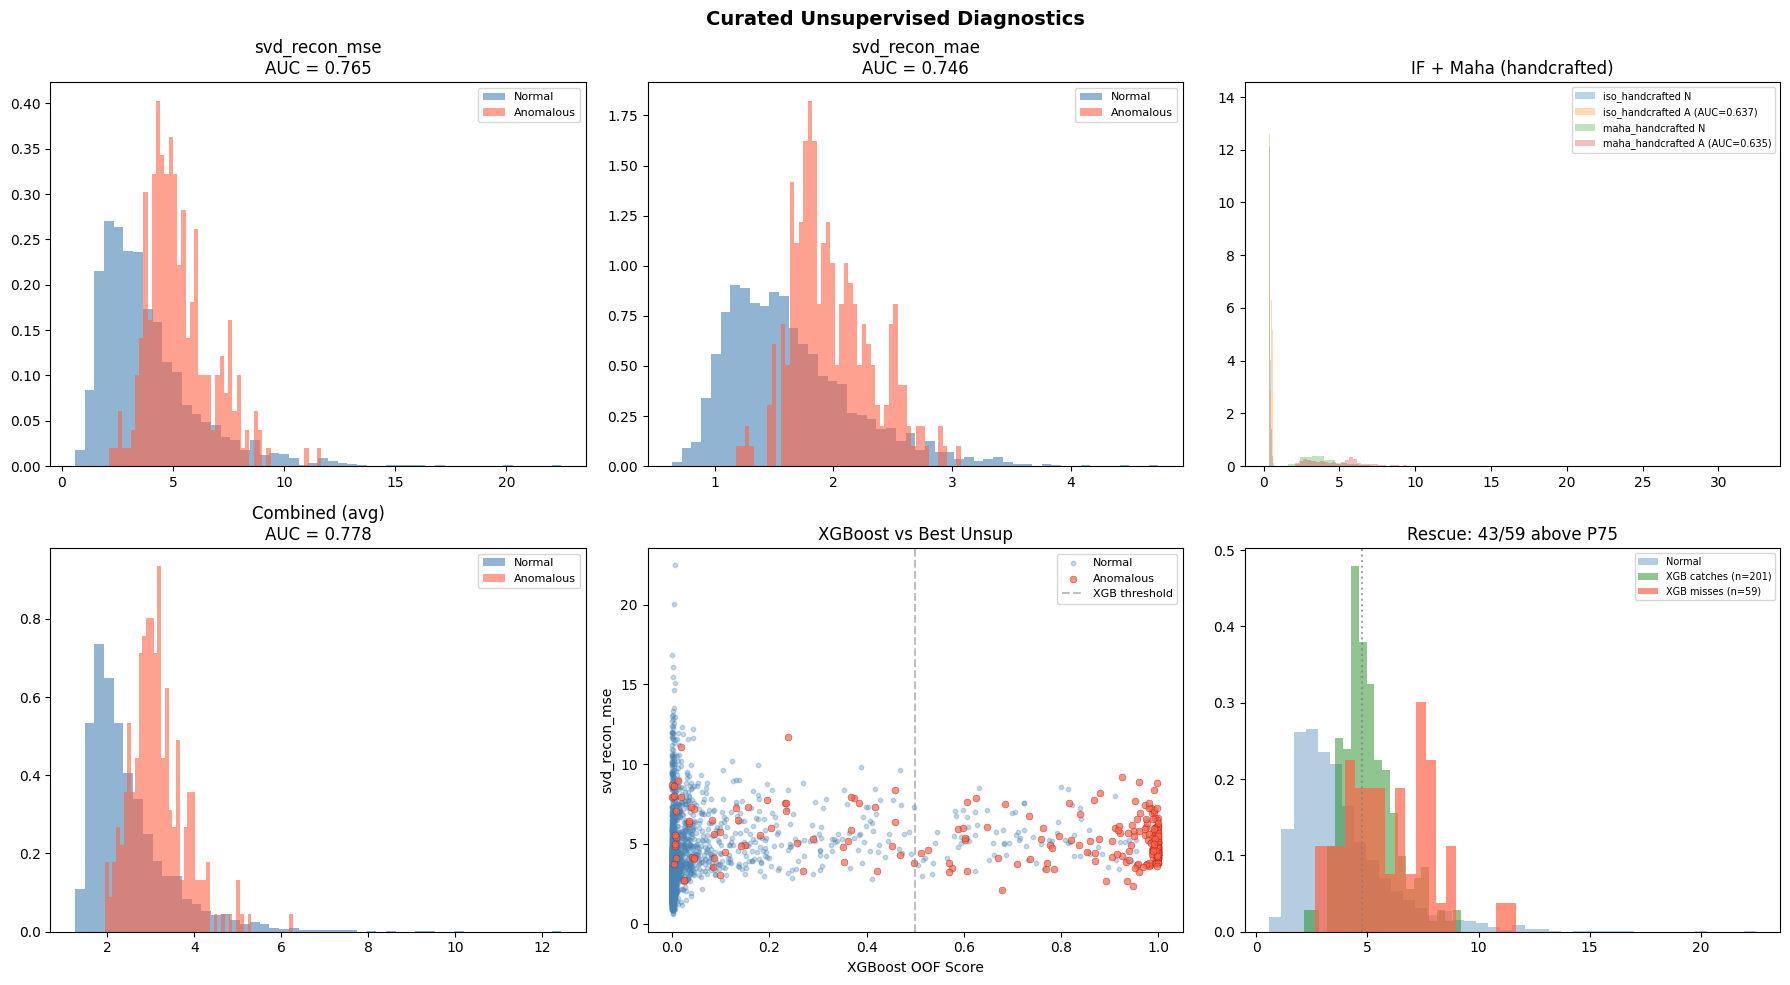


── Per-score AUCs ─────────────────────────────────────
  svd_recon_mse             AUC = 0.765
  svd_recon_mae             AUC = 0.746
  iso_handcrafted           AUC = 0.637
  maha_handcrafted          AUC = 0.635
  combined                  AUC = 0.778

XGBoost OOF AUC: 0.963
Missed: 59/260
  rescuable: 43/59
→ Moderate. BLEND_ALPHA = 0.15–0.25


In [ ]:
# ── Unsupervised Score Diagnostics ────────────────────────────────────

unsup_idxs = [feature_cols_all.index(c) for c in UNSUP_COLS]
unsup_matrix = X_trainval_s[:, unsup_idxs]

labels_bool = y_trainval.astype(bool)
normal_mask = ~labels_bool
anom_mask   = labels_bool

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Curated Unsupervised Diagnostics", fontsize=14, fontweight="bold")

# Row 1: per-score distributions
for i, (ax, name) in enumerate(zip(axes[0], UNSUP_COLS[:3])):
    vals_n = unsup_matrix[normal_mask, i]
    vals_a = unsup_matrix[anom_mask, i]
    ax.hist(vals_n, bins=50, alpha=0.6, label="Normal", density=True, color="steelblue")
    ax.hist(vals_a, bins=50, alpha=0.6, label="Anomalous", density=True, color="tomato")
    auc_i = roc_auc_score(y_trainval, unsup_matrix[:, i])
    ax.set_title(f"{name}\nAUC = {auc_i:.3f}")
    ax.legend(fontsize=8)

# Row 1, slot 3: 4th score if exists
if len(UNSUP_COLS) > 3:
    ax = axes[0][2]
    ax.clear()
    for i in [2, 3]:
        vals_a = unsup_matrix[anom_mask, i]
        vals_n = unsup_matrix[normal_mask, i]
        auc_i = roc_auc_score(y_trainval, unsup_matrix[:, i])
        ax.hist(vals_n, bins=40, alpha=0.3, density=True, label=f"{UNSUP_COLS[i]} N")
        ax.hist(vals_a, bins=40, alpha=0.3, density=True, label=f"{UNSUP_COLS[i]} A (AUC={auc_i:.3f})")
    ax.set_title("IF + Maha (handcrafted)")
    ax.legend(fontsize=7)

# Row 2, Left: combined
ax = axes[1][0]
combined = unsup_matrix.mean(axis=1)
ax.hist(combined[normal_mask], bins=50, alpha=0.6, label="Normal", density=True, color="steelblue")
ax.hist(combined[anom_mask], bins=50, alpha=0.6, label="Anomalous", density=True, color="tomato")
auc_combined = roc_auc_score(y_trainval, combined)
ax.set_title(f"Combined (avg)\nAUC = {auc_combined:.3f}")
ax.legend(fontsize=8)

# Row 2, Middle: XGBoost vs best unsupervised
ax = axes[1][1]
unsup_aucs = [roc_auc_score(y_trainval, unsup_matrix[:, i]) for i in range(unsup_matrix.shape[1])]
best_idx = np.argmax(unsup_aucs)
best_unsup = unsup_matrix[:, best_idx]
ax.scatter(oof_scores[normal_mask], best_unsup[normal_mask], alpha=0.3, s=10, c="steelblue", label="Normal")
ax.scatter(oof_scores[anom_mask], best_unsup[anom_mask], alpha=0.7, s=25, c="tomato", label="Anomalous",
           edgecolors="darkred", linewidths=0.3)
ax.axvline(0.5, color="gray", ls="--", alpha=0.5, label="XGB threshold")
ax.set_xlabel("XGBoost OOF Score")
ax.set_ylabel(f"{UNSUP_COLS[best_idx]}")
ax.set_title("XGBoost vs Best Unsup")
ax.legend(fontsize=8)

# Row 2, Right: rescue
ax = axes[1][2]
xgb_missed = anom_mask & (oof_scores < 0.5)
n_missed = xgb_missed.sum()
n_caught = (anom_mask & (oof_scores >= 0.5)).sum()
if n_missed > 0:
    unsup_missed = best_unsup[xgb_missed]
    unsup_normal = best_unsup[normal_mask]
    p75 = np.percentile(unsup_normal, 75)
    rescuable = (unsup_missed > p75).sum()
    ax.hist(unsup_normal, bins=40, alpha=0.4, density=True, color="steelblue", label="Normal")
    ax.hist(best_unsup[anom_mask & (oof_scores >= 0.5)], bins=20, alpha=0.5, density=True, color="forestgreen", label=f"XGB catches (n={n_caught})")
    ax.hist(unsup_missed, bins=20, alpha=0.7, density=True, color="tomato", label=f"XGB misses (n={n_missed})")
    ax.axvline(p75, color="gray", ls=":", alpha=0.7)
    ax.set_title(f"Rescue: {rescuable}/{n_missed} above P75")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("\n── Per-score AUCs ─────────────────────────────────────")
for name, auc in zip(UNSUP_COLS, unsup_aucs):
    print(f"  {name:25s} AUC = {auc:.3f}")
print(f"  {"combined":25s} AUC = {auc_combined:.3f}")
print(f"\nXGBoost OOF AUC: {roc_auc_score(y_trainval, oof_scores):.3f}")
print(f"Missed: {n_missed}/{anom_mask.sum()}")
if n_missed > 0:
    print(f"  rescuable: {rescuable}/{n_missed}")
if auc_combined > 0.85 and n_missed > 0 and rescuable / max(n_missed, 1) > 0.4:
    print("→ Strong. BLEND_ALPHA = 0.25–0.35")
elif auc_combined > 0.75 and n_missed > 0 and rescuable / max(n_missed, 1) > 0.2:
    print("→ Moderate. BLEND_ALPHA = 0.15–0.25")
else:
    print("→ Weak. BLEND_ALPHA = 0.10–0.15 or disable.")


#### **Model Predictions**

In [ ]:
# Load test data
XX_test, _ = load_npz("data/third_batch.npz")

In [ ]:
# ── Test predictions ──────────────────────────────────────────────────
fold_test_preds = []

for fold_id, art in enumerate(fold_artifacts, 1):
    model           = art["model"]
    item_stats_fold = art["item_stats"]
    feat_cols_fold  = art["feature_cols"]
    scaler_fold     = art["scaler"]
    normal_users_fold = art["normal_users"]
    struct_refs_fold  = art["struct_refs"]  # FIX 1: use fold's training refs

    # Build test features using this fold's training-derived refs
    test_df = build_all_features(XX_test, item_stats_fold, struct_refs_fold)
    hc_cols_fold = [c for c in feat_cols_fold if c not in UNSUP_COLS]

    for c in hc_cols_fold:
        if c not in test_df.columns:
            test_df[c] = 0.0

    X_test_hc_s = scaler_fold.transform(test_df[hc_cols_fold].values)

    # Unsupervised scores for test
    ref_df = build_all_features(XX_all, item_stats_fold, struct_refs_fold)
    for c in hc_cols_fold:
        if c not in ref_df.columns:
            ref_df[c] = 0.0
    X_ref_hc_s = scaler_fold.transform(ref_df[hc_cols_fold].values)
    ref_labels = ref_df.merge(yy_all, on="user", how="left")["label"].values

    unsup_test, _ = build_unsupervised_scores(
        XX_ref=XX_all, XX_target=XX_test,
        target_users=test_df["user"].values,
        ref_normal_users=normal_users_fold,
        X_handcrafted_ref=X_ref_hc_s,
        X_handcrafted_target=X_test_hc_s,
        ref_labels=ref_labels,
    )

    X_test_final = np.hstack([X_test_hc_s, unsup_test])
    p_test = model.predict_proba(X_test_final)[:, 1]
    fold_test_preds.append(p_test)
    print(f"Generated test predictions from fold {fold_id:02d}")

fold_test_preds = np.column_stack(fold_test_preds)
y_score_raw = fold_test_preds.mean(axis=1)

# ── Standalone SVD recon MSE for blending ─────────────────────────
unsup_blend, _ = build_unsupervised_scores(
    XX_ref=XX_all, XX_target=XX_test,
    target_users=build_all_features(XX_test, item_stats_full, struct_refs_full)["user"].values,
    ref_normal_users=normal_users_all,
    X_handcrafted_ref=X_hc_s,
    X_handcrafted_target=scaler.transform(
        build_all_features(XX_test, item_stats_full, struct_refs_full)
        .reindex(columns=hc_cols, fill_value=0).values
    ),
    ref_labels=y_trainval,
)
recon_mse_test = unsup_blend[:, 0]
recon_norm = (recon_mse_test - recon_mse_test.min()) / (
    recon_mse_test.max() - recon_mse_test.min() + 1e-9
)

print(f"\nXGBoost raw range:  [{y_score_raw.min():.4f}, {y_score_raw.max():.4f}]")
print(f"SVD recon range:    [{recon_norm.min():.4f}, {recon_norm.max():.4f}]")

# Blend (same BLEND_ALPHA as calibration cell)
y_blended = (1 - BLEND_ALPHA) * y_score_raw + BLEND_ALPHA * recon_norm

# FIX 2: Calibrator was trained on blended scores, so this now matches
y_score_cal = calibrator.predict_proba(y_blended.reshape(-1, 1))[:, 1]
y_score_norm = (y_score_cal - y_score_cal.min()) / (
    y_score_cal.max() - y_score_cal.min() + 1e-9
)

print(f"\nFinal shape: {y_score_norm.shape}")
print(f"Final range: [{y_score_norm.min():.4f}, {y_score_norm.max():.4f}]")


Generated test predictions from fold 01
Generated test predictions from fold 02
Generated test predictions from fold 03
Generated test predictions from fold 04
Generated test predictions from fold 05

XGBoost raw range:  [0.0002, 0.9987]
SVD recon range:    [0.0000, 1.0000]

Final shape: (1625,)
Final range: [0.0000, 1.0000]


#### **Evaluation (local/Codabench)**

In [ ]:
# Save submission
np.savez("submission.npz", predictions=y_score_norm)
with zipfile.ZipFile("submission.zip", "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write("submission.npz", arcname="submission.npz")
pd.DataFrame({"predictions": y_score_norm}).to_csv("submission.csv", index=False)
print("submission.zip ready for Codabench")

submission.zip ready for Codabench


results not submitted to codabench